In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

sys.path.append(str(Path.cwd().parent))
from src.models.predict_model import load_model,load_test_data, run_prediction_evaluation, get_r2_by_threshold,get_mae_by_threshold,get_mae_by_loadtype, get_mae_by_daytype
from src.visualization.visualize import plot_score_comparison_chart,plot_bar, plot_kpi_with_threshold

sys.path.append('..')

%load_ext autoreload
%autoreload 2

# 1. Load Finalist Trained Models

In [3]:

loaded_models = load_model()
loaded_models

✅ Success: Model found at D:\All Practice Projects\Git Hub Projects\Steel Industry Energy Consumption\models\randomforest_regression_pipeline.pkl
✅ Success: Model found at D:\All Practice Projects\Git Hub Projects\Steel Industry Energy Consumption\models\xgboost_pipeline.pkl
✅ 2 model(s) successfully loaded.


[Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['nsm_sin', 'nsm_cos',
                                                    'nsm_sin_loadtype',
                                                    'nsm_cos_loadtype',
                                                    'is_weekend',
                                                    'electrical_load',
                                                    'usage_lag_1', 'usage_lag_4',
                                                    'usage_rolling_mean_4',
                                                    'usage_rolling_std_4']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   [])])),
                 ('regressor',
                  RandomForestRegressor(max_depth=10, min_sampl

# 2. Load Test Data

In [4]:
df_test, X_test, y_test = load_test_data()

test data successfully loaded.


# 3. Evaluation By Business Requirement

Let's assume business context and thresholds are as following; 

**Business KPI Table**
| Metric                  | Business Meaning                                                            | Target/Threshold               |
| ------------------------| --------------------------------------------------------------------------- | -------------------------------|
| R2                      | Explains usage patterns using only forecast-safe (pre-consumption) features | >= 0.75                        |
| MAE                     | Average prediction error, vs naive persistence baseline                     | ≥ 30% improvement over baseline|
| MAE by Load_Type        | Consistency of error across Light/Medium/Maximum load                       |  No class > 1.5× overall MAE   |
| MAE (weekday − weekend) | Error stability across day types                                            | < 5 kWh                        |




## 3.1 Run full KPI evaluation - Random Forest Regressor


In [5]:
mdl_rdf = loaded_models[0].named_steps['regressor'].__class__.__name__
mdl_rdf

'RandomForestRegressor'

In [6]:
pipeline_rdf = loaded_models[0]
pipeline_rdf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['nsm_sin','nsm_cos','nsm_sin_loadtype',...,'usage_lag_4', 'usage_rolling_mean_4','usage_rolling_std_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pas

In [7]:

# get R2 and MAE value
result_rdf = run_prediction_evaluation(pipeline_rdf, X_test, y_test)

dic_r2 = {'Model':mdl_rdf, 'R2':result_rdf['R2']}
dic_mae = {'Model':mdl_rdf, 'MAE':result_rdf['MAE']}

# Evaluation 1 - R2 >= Threshold 0.75
sla_threshold = 0.70
df_r2_thshd_rdf = get_r2_by_threshold(pd.DataFrame([dic_r2]), sla_threshold)

# Evaluation 2 - MAE value greater than or equal 30% improvement over baseline
df_mae_thshd_rdf = get_mae_by_threshold(pd.DataFrame([dic_mae]), df_test)

# Evaluation 3 - MAE by Load_Type not more than 1.5 times of overall MAE
overall_mae_threshold = 1.5
target = 'Usage_kWh'
df_ltype_thshd_rdf = get_mae_by_loadtype(pipeline_rdf,df_test,X_test, target, overall_mae_threshold)

# Evaluation 4 - MAE by day type (weekday/weekend) less than 5 kWh
usage_threshold = 5
df_dtype_thshd_rdf = get_mae_by_daytype(pipeline_rdf,df_test,X_test,target,usage_threshold)


### 3.1.1 Conclusion on Randowm Forest Regressor

In [8]:

mae_threshold_pct = 30.0
df_mae_thshd_rdf['Pass_Threshold'] = np.where(df_mae_thshd_rdf['MAE_imprv_percent'] >= mae_threshold_pct, 'Pass', 'Fail')

print("=== Random Forest — full KPI scorecard ===")
print(f"\n1)Evaluation 1 - R2 >= 0.75:\n{df_r2_thshd_rdf.to_markdown()}")
print(f"\n2)Evaluation 2 - MAE improvement >= {mae_threshold_pct}% vs naive baseline:\n{df_mae_thshd_rdf.to_markdown()}")
print(f"\n3)Evaluation 3 - MAE by Load_Type <= 1.5x overall MAE (all load types):\n{df_ltype_thshd_rdf.to_markdown()}")
print(f"\n4)Evaluation 4 - MAE gap weekday/weekend < 5 kWh:\n{df_dtype_thshd_rdf.to_markdown()}")

=== Random Forest — full KPI scorecard ===

1)Evaluation 1 - R2 >= 0.75:
|    | Model                 |     R2 | Pass_Threshold   |
|---:|:----------------------|-------:|:-----------------|
|  0 | RandomForestRegressor | 0.9259 | Pass             |

2)Evaluation 2 - MAE improvement >= 30.0% vs naive baseline:
|    | Model                 |    MAE |   MAE_Baseline |   MAE_imprv_percent | Pass_Threshold   |
|---:|:----------------------|-------:|---------------:|--------------------:|:-----------------|
|  0 | RandomForestRegressor | 3.9477 |         5.4171 |             27.1254 | Fail             |

3)Evaluation 3 - MAE by Load_Type <= 1.5x overall MAE (all load types):
| Load_Type    |   Overall MAE |   MAE_by_loadtype | Pass_Threshold   |
|:-------------|--------------:|------------------:|:-----------------|
| Light_Load   |       3.94771 |           1.19596 | Pass             |
| Maximum_Load |       3.94771 |           7.67161 | Fail             |
| Medium_Load  |       3.94771 | 

In [9]:

print(f"Random Forest Regressor achieves a high R² of {df_r2_thshd_rdf['R2'][0]}; however, its MAE of {df_mae_thshd_rdf['MAE_imprv_percent'][0]}% does not meet the required 30% improvement over the baseline.\nAmong the load types, only the Light Load category has an MAE within 1.5 times the overall MAE.\nNevertheless, the model maintains a relatively small MAE gap of less than 5 kWh between weekend and weekday predictions.")

Random Forest Regressor achieves a high R² of 0.9259; however, its MAE of 27.1254% does not meet the required 30% improvement over the baseline.
Among the load types, only the Light Load category has an MAE within 1.5 times the overall MAE.
Nevertheless, the model maintains a relatively small MAE gap of less than 5 kWh between weekend and weekday predictions.


## 3.2 Run full KPI evaluation - XGBoost

In [10]:
mdl_xgb = loaded_models[1].named_steps['regressor'].__class__.__name__
mdl_xgb

'XGBRegressor'

In [11]:
pipeline_xgb = loaded_models[1]
pipeline_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['nsm_sin','nsm_cos','nsm_sin_loadtype',...,'usage_lag_4', 'usage_rolling_mean_4','usage_rolling_std_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pas

In [12]:
# get R2 and MAE value
result_xgb = run_prediction_evaluation(pipeline_xgb, X_test, y_test)

dic_r2 = {'Model':mdl_xgb, 'R2':result_xgb['R2']}
dic_mae = {'Model':mdl_xgb, 'MAE':result_xgb['MAE']}

# Evaluation 1 - R2 >= Threshold 0.75
sla_threshold = 0.70
df_r2_thshd_xgb = get_r2_by_threshold(pd.DataFrame([dic_r2]), sla_threshold)

# Evaluation 2 - MAE value greater than or equal 30% improvement over baseline
df_mae_thshd_xgb = get_mae_by_threshold(pd.DataFrame([dic_mae]), df_test)

# Evaluation 3 - MAE by Load_Type not more than 1.5 times of overall MAE
overall_mae_threshold = 1.5
target = 'Usage_kWh'
df_ltype_thshd_xgb = get_mae_by_loadtype(pipeline_xgb,df_test,X_test, target, overall_mae_threshold)

# Evaluation 4 - MAE by day type (weekday/weekend) less than 5 kWh
usage_threshold = 5
df_dtype_thshd_xgb = get_mae_by_daytype(pipeline_xgb,df_test,X_test,target,usage_threshold)

### 3.2.1 Conclusion on XGBoost Regressor

In [13]:
mae_threshold_pct = 30.0
df_mae_thshd_xgb['Pass_Threshold'] = np.where(df_mae_thshd_xgb['MAE_imprv_percent'] >= mae_threshold_pct, 'Pass', 'Fail')

print("\n=== XGBoost — full KPI scorecard ===")
print(f"\n1) R2 >= 0.75:\n{df_r2_thshd_xgb.to_markdown()}")
print(f"\n2) MAE improvement >= {mae_threshold_pct}% vs naive baseline:\n{df_mae_thshd_xgb.to_markdown()}")
print(f"\n3) MAE by Load_Type <= 1.5x overall MAE (all load types):\n{df_ltype_thshd_xgb.to_markdown()}")
print(f"\n4) MAE gap weekday/weekend < 5 kWh:\n{df_dtype_thshd_xgb.to_markdown()}")


=== XGBoost — full KPI scorecard ===

1) R2 >= 0.75:
|    | Model        |     R2 | Pass_Threshold   |
|---:|:-------------|-------:|:-----------------|
|  0 | XGBRegressor | 0.9257 | Pass             |

2) MAE improvement >= 30.0% vs naive baseline:
|    | Model        |    MAE |   MAE_Baseline |   MAE_imprv_percent | Pass_Threshold   |
|---:|:-------------|-------:|---------------:|--------------------:|:-----------------|
|  0 | XGBRegressor | 4.0995 |         5.4171 |             24.3231 | Fail             |

3) MAE by Load_Type <= 1.5x overall MAE (all load types):
| Load_Type    |   Overall MAE |   MAE_by_loadtype | Pass_Threshold   |
|:-------------|--------------:|------------------:|:-----------------|
| Light_Load   |        4.0995 |           1.22678 | Pass             |
| Maximum_Load |        4.0995 |           8.12997 | Fail             |
| Medium_Load  |        4.0995 |           6.92339 | Fail             |

4) MAE gap weekday/weekend < 5 kWh:
|    |   Weekday MAE |   

In [14]:
print(f"XGBoost Regressor achieves a high R² of {df_r2_thshd_xgb['R2'][0]}; however, its MAE of {df_mae_thshd_xgb['MAE_imprv_percent'][0]}% does not meet the required 30% improvement over the baseline.\nAmong the load types, only the Light Load category has an MAE within 1.5 times the overall MAE.\nHowever, the model maintains a relatively small MAE gap {round(df_dtype_thshd_xgb['MAE_gap_by_daytype'][0],4)} of less than 5 kWh between weekend and weekday predictions.")

XGBoost Regressor achieves a high R² of 0.9257; however, its MAE of 24.3231% does not meet the required 30% improvement over the baseline.
Among the load types, only the Light Load category has an MAE within 1.5 times the overall MAE.
However, the model maintains a relatively small MAE gap 3.2499 of less than 5 kWh between weekend and weekday predictions.


# 4. Evaluation Summary

In [15]:
best_model = 'Random Forest' if result_rdf['MAE'] < result_xgb['MAE'] else 'XGBoost'
best_mae = result_rdf['MAE'] if best_model == 'Random Forest' else result_xgb['MAE']

r2_row = df_r2_thshd_rdf if best_model == 'Random Forest' else df_r2_thshd_xgb
mae_row = df_mae_thshd_rdf if best_model == 'Random Forest' else df_mae_thshd_xgb
dtype_row = df_dtype_thshd_rdf if best_model == 'Random Forest' else df_dtype_thshd_xgb
ltype_tbl = df_ltype_thshd_rdf if best_model == 'Random Forest' else df_ltype_thshd_xgb
fails = (ltype_tbl['Pass_Threshold'] == 'Fail').sum()
total = len(ltype_tbl)

summary_md = f"""

| KPI | Result | Threshold | Verdict |
|---|---|---|---|
| R² | {r2_row['R2'].iloc[0]:.3f} | ≥ 0.75 | {r2_row['Pass_Threshold'].iloc[0]} |
| MAE improvement vs. baseline | {mae_row['MAE_imprv_percent'].iloc[0]:.1f}% | ≥ 30% | {mae_row['Pass_Threshold'].iloc[0]} |
| MAE by Load_Type | {total - fails}/{total} segments pass | ≤ 1.5× overall MAE | {'Pass' if fails == 0 else f'{fails} segment(s) fail'} |
| Weekday/weekend MAE gap | {dtype_row['MAE_gap_by_daytype'].iloc[0]:.2f} kWh | < 5 kWh | {dtype_row['Pass_Threshold'].iloc[0]} |

"""
display(Markdown(summary_md))



| KPI | Result | Threshold | Verdict |
|---|---|---|---|
| R² | 0.926 | ≥ 0.75 | Pass |
| MAE improvement vs. baseline | 27.1% | ≥ 30% | Fail |
| MAE by Load_Type | 1/3 segments pass | ≤ 1.5× overall MAE | 2 segment(s) fail |
| Weekday/weekend MAE gap | 3.06 kWh | < 5 kWh | Pass |



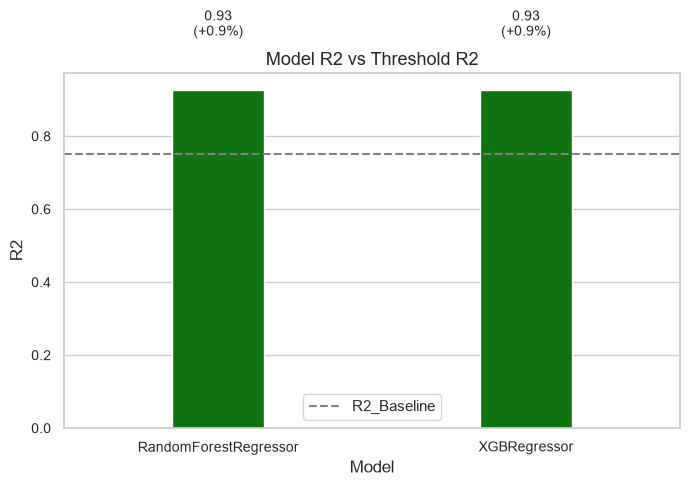

,Model,R2,Pass_Threshold,R2_Baseline
0,RandomForestRegressor,0.9259,Pass,0.75
1,XGBRegressor,0.9257,Pass,0.75


In [25]:
df_r2_thshd_combine = pd.concat([df_r2_thshd_rdf, df_r2_thshd_xgb], ignore_index=True)
df_r2_thshd_combine['R2_Baseline'] = 0.75
plot_kpi_with_threshold(df= df_r2_thshd_combine,
                        kpi_col='R2',
                        threshold_col='R2_Baseline',
                        threshold_label='R2_Baseline',
                        ylabel='R2',
                        title='Model R2 vs Threshold R2')
df_r2_thshd_combine

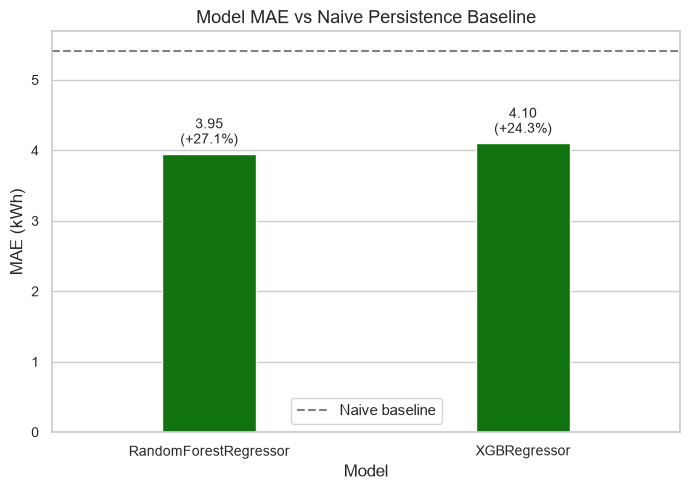

,Model,MAE,MAE_Baseline,MAE_imprv_percent,Pass_Threshold
0,RandomForestRegressor,3.9477,5.4171,27.1254,Fail
1,XGBRegressor,4.0995,5.4171,24.3231,Fail


In [24]:
# plot MAE improvement over baseline threshold
df_mae_thshd_combine = pd.concat([df_mae_thshd_rdf, df_mae_thshd_xgb], ignore_index=True)
plot_kpi_with_threshold(df = df_mae_thshd_combine,
                        kpi_col= 'MAE',
                        threshold_col='MAE_Baseline',
                        threshold_label='Naive baseline',
                        ylabel='MAE (kWh)',
                        title='Model MAE vs Naive Persistence Baseline')
df_mae_thshd_combine

# 5. Best Model


**Random Forest** clears the accuracy and day-type stability checks comfortably, but falls short of the 30% baseline-improvement target. 
Two things are worth noting about the baseline-improvement miss specifically: the 30% target implicitly compares against 15-minute persistence (predicting "same as last reading"), which is already a strong predictor for this data since industrial load rarely shifts much in 15 minutes.

**Recommendation:** Random Forest is suitable for shift-level demand planning and general monitoring, where this level of accuracy is useful. Before treating it as production-ready for tighter use cases (e.g. automated load-shedding triggers), two things should be addressed: the same-window leakage risk in the `electrical_load` feature (see feature engineering notes), and further tuning aimed specifically at [whichever load type fails, once confirmed] where error is proportionally highest.